### Assignments chapter 2
c: write a script that can generate trajectories for bacteria motion based on the probability distribution 2.3.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# rewriting what we already had to a function

def rejection_sampling_generator(A=0.7,N=5000,r=1):
    x = 0
    y = 0

    X = np.zeros(N)
    Y = np.zeros(N)

    for i in range(N):

        accepted = False

        while accepted == False:

            phi = 2*np.pi*np.random.rand()

            P = (1 + A*np.cos(phi)) / (2*np.pi)
            Pmax = (1 + A) / (2*np.pi)

            test = Pmax*np.random.rand()

            if test <= P:
                accepted = True

        x = x + r*np.cos(phi)
        y = y + r*np.sin(phi)

        X[i]=x
        Y[i]=y
    return X, Y


# numerical calculation of variance of each step
def variance_num(A, N, r, n_trajectories=1000):

    final_X = np.zeros(n_trajectories)

    for i in range(n_trajectories):
        X, _ = rejection_sampling_generator(A, N, r)

        final_X[i]=X[-1]

    Xsquared_then_mean = np.mean(final_X**2)
    Xmean_then_squared = np.mean(final_X)**2

    return Xsquared_then_mean - Xmean_then_squared


# analytical calculation of variance of each step
def variance_theory(A,N,r):
    return 0.5 * N * r**2 * (1 - 0.5 * A**2)

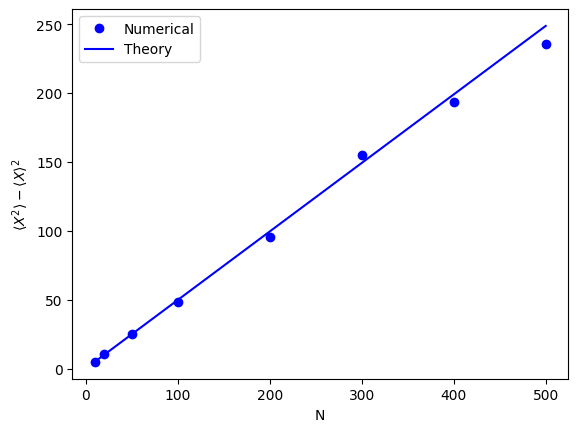

In [31]:
# Calculating and plotting

A = 0.7
r = 1

A_values = [0.1]
colors = ['b']
N_values = [10, 20, 50, 100, 200, 300, 400, 500]

variance_numerical = np.zeros(len(N_values))
variance_analytical = np.zeros(len(N_values))
for j in range(len(A_values)):
    for i in range(len(N_values)):

        variance_numerical[i] = variance_num(A_values[j], N_values[i], r, n_trajectories=1000)

        variance_analytical[i] = variance_theory(A_values[j], N_values[i], r)


    plt.plot(N_values, variance_numerical, "o", color=colors[j],  label="Numerical")
    plt.plot(N_values, variance_analytical,  color=colors[j], label="Theory")

plt.xlabel("N")
plt.ylabel(r"$\langle X^2\rangle - \langle X\rangle^2$")
plt.legend()
plt.show()
